 # Groundwater Level Forecasting – 3-Layer LSTM (Full Notebook)

 This notebook performs:
 - Time selection
 - Feature engineering
 - Leak-free Train/Val/Test split
 - Scaling (train-only)
 - Sliding-window dataset creation
 - Grid Search for LSTM
 - Final retraining
 - Evaluation
 - Permutation Feature Importance
 - SHAP interpretability

## 0. Imports

In [1]:
%pip install tensorflow shap

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import shap

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.1)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

print("TensorFlow:", tf.__version__)

Note: you may need to restart the kernel to use updated packages.
TensorFlow: 2.19.0


## 1. Load and Merge Data

In [2]:
# ======================================================
# Paths
# ======================================================
BASE_PATH = "."

path_level_rain_pressure = os.path.join(
    BASE_PATH, "data/nivel-pocos_chuva_pressao_tratados.csv"
)
path_wells_func = os.path.join(
    BASE_PATH, "data/funcionamento_pocos_30min.csv"
)
path_earth_tide = os.path.join(
    BASE_PATH, "data/earth_tide.csv"
)

# ======================================================
# Load data
# ======================================================
level_rain_pressure = pd.read_csv(path_level_rain_pressure)
wells_func = pd.read_csv(path_wells_func)
earth_tide = pd.read_csv(path_earth_tide)

# ======================================================
# Standardize datetime column
# ======================================================
if "datetime" in earth_tide.columns:
    earth_tide = earth_tide.rename(columns={"datetime": "date_time"})

for df_ in [level_rain_pressure, wells_func, earth_tide]:
    if "date_time" not in df_.columns:
        raise ValueError("Dataset missing 'date_time' column.")

# ======================================================
# Rename variables (standard naming)
# ======================================================
rename_map = {
    "pressao_mH2O_final": "baro_ig_mH2O",
    "gmu_level_mH2O_compensado": "gmu_gwl_mH2O",
    "chuva_mm_30min": "rain_mm_30min",
    "status_IMECC": "status_IME",
    "status_ZOOLOGIA": "status_IBZ",
}

level_rain_pressure = level_rain_pressure.rename(columns=rename_map)
wells_func = wells_func.rename(columns=rename_map)

# ======================================================
# Clean pumping status (binary)
# ======================================================
wells_func = wells_func.dropna()
pumping_cols = wells_func.columns.difference(["date_time"])
wells_func[pumping_cols] = wells_func[pumping_cols].astype(int)

# ======================================================
# Merge datasets
# ======================================================
data = (
    level_rain_pressure
    .merge(wells_func, on="date_time", how="outer")
    .merge(earth_tide, on="date_time", how="outer")
)

data["date_time"] = pd.to_datetime(data["date_time"])
data = data.sort_values("date_time").reset_index(drop=True)

print("Merged shape:", data.shape)

Merged shape: (70080, 8)


## 1.1 Filter Period

In [3]:
# ======================================================
# Filter analysis period
# ======================================================
START_DATE = "2024-12-08 23:00:00"
END_DATE   = "2025-08-14 16:00:00"

data = data[
    (data["date_time"] >= START_DATE) &
    (data["date_time"] <= END_DATE)
].copy()

print(f"Using period {START_DATE} → {END_DATE}")
print("Shape after filtering:", data.shape)

# ======================================================
# Set time index
# ======================================================
df = data.set_index("date_time").copy()

Using period 2024-12-08 23:00:00 → 2025-08-14 16:00:00
Shape after filtering: (11939, 8)


## 2. Feature Engineering (NO dropna)

In [4]:
# ======================================================
# CONFIGURATION: engineered feature selection strategy
# ======================================================

# Options:
# "all"      -> use all engineered features
# "lag_only" -> use only gwl_lag_6h
ENGINEERED_MODE = "all"   # <<< ALTERE AQUI

# ======================================================
# Target
# ======================================================
target_col = "gmu_gwl_mH2O"

# ======================================================
# Feature engineering
# ======================================================

# -----------------------
# Autoregressive features
# -----------------------
df["gwl_lag_6h"] = df[target_col].shift(12)           # 6h = 12 × 30 min
df["gwl_diff_24h"] = df[target_col] - df[target_col].shift(48)  # 24h

# -----------------------
# Trend (low-pass filter)
# -----------------------
# 7 days = 7 × 24 × 2 = 336 steps
df["trend_component"] = (
    df[target_col]
    .rolling(window=336, center=True, min_periods=1)
    .mean()
)

# -----------------------
# Pumping aggregation
# -----------------------
pumping_cols = ["status_IME", "status_FEF", "status_IBZ"]
df["pumping_total"] = df[pumping_cols].sum(axis=1)

df["pumping_sum_7d"] = (
    df["pumping_total"]
    .rolling(window=336, min_periods=1)
    .sum()
)

# -----------------------
# Rainfall aggregation
# -----------------------
df["rain_sum_7d"] = (
    df["rain_mm_30min"]
    .rolling(window=336, min_periods=1)
    .sum()
)

# -----------------------
# Calendar feature
# -----------------------
df["weekday"] = (df.index.weekday < 5).astype(int)

# ======================================================
# Engineered feature selection (CONTROLLED)
# ======================================================

engineered_features_all = [
    "gwl_lag_6h",
    "gwl_diff_24h",
    "trend_component",
    "pumping_sum_7d",
    "rain_sum_7d",
    "weekday",
]

if ENGINEERED_MODE == "all":
    engineered_features = engineered_features_all

elif ENGINEERED_MODE == "lag_only":
    engineered_features = ["gwl_lag_6h"]

else:
    raise ValueError(
        "Invalid ENGINEERED_MODE. Use 'all' or 'lag_only'."
    )

# ======================================================
# Natural features (original variables only)
# ======================================================

excluded_cols = (
    [target_col] +
    engineered_features_all +   # remove ALL engineered cols from naturals
    ["pumping_total"]           # internal helper variable
)

natural_features = [
    col for col in df.columns
    if col not in excluded_cols
]

# ======================================================
# Final feature set (conditional)
# ======================================================

if ENGINEERED_MODE == "lag_only":
    candidate_features = ["gwl_lag_6h"]
else:
    candidate_features = natural_features + engineered_features

print("Engineered mode:", ENGINEERED_MODE)

print("\nFinal selected features:")
print(candidate_features)

# ======================================================
# Final modeling dataframe
# ======================================================
df_model = df[[target_col] + candidate_features].copy()

# ------------------------------------------------------
# Valid mask (ESSENTIAL)
# ------------------------------------------------------
valid_mask = df_model.notna().all(axis=1).values

print("Final modeling shape:", df_model[valid_mask].shape)


Engineered mode: all

Final selected features:
['baro_ig_mH2O', 'rain_mm_30min', 'status_IME', 'status_FEF', 'status_IBZ', 'earth_tide_nm/s2', 'gwl_lag_6h', 'gwl_diff_24h', 'trend_component', 'pumping_sum_7d', 'rain_sum_7d', 'weekday']
Final modeling shape: (11891, 13)


## 3. Train / Val / Test Split (Masked)

In [5]:
X_all = df_model[candidate_features].values
y_all = df_model[[target_col]].values

n = len(df_model)
train_end = int(n * 0.7)
val_end   = int(n * 0.85)

def masked_split(X, y, mask, a, b):
    return X[a:b], y[a:b], mask[a:b]

X_train_raw, y_train_raw, mask_train = masked_split(X_all, y_all, valid_mask, 0, train_end)
X_val_raw,   y_val_raw,   mask_val   = masked_split(X_all, y_all, valid_mask, train_end, val_end)
X_test_raw,  y_test_raw,  mask_test  = masked_split(X_all, y_all, valid_mask, val_end, n)

## 4. Scaling (fit only on valid TRAIN)

In [6]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaler_X.fit(X_train_raw[mask_train])
scaler_y.fit(y_train_raw[mask_train])

X_train_scaled = scaler_X.transform(X_train_raw)
X_val_scaled   = scaler_X.transform(X_val_raw)
X_test_scaled  = scaler_X.transform(X_test_raw)

y_train_scaled = scaler_y.transform(y_train_raw)
y_val_scaled   = scaler_y.transform(y_val_raw)
y_test_scaled  = scaler_y.transform(y_test_raw)

## 5. Sequence Creation (NO gaps)

In [7]:
def create_sequences_masked(X, y, mask, window):
    Xs, ys = [], []
    for i in range(window, len(X)):
        if not mask[i-window:i+1].all():
            continue
        Xs.append(X[i-window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

window_size = 240

X_train, y_train = create_sequences_masked(X_train_scaled, y_train_scaled, mask_train, window_size)
X_val,   y_val   = create_sequences_masked(X_val_scaled,   y_val_scaled,   mask_val,   window_size)
X_test,  y_test  = create_sequences_masked(X_test_scaled,  y_test_scaled,  mask_test,  window_size)

print("Final sequences:")
print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Final sequences:
Train: (8069, 240, 12)
Val:   (1551, 240, 12)
Test:  (1551, 240, 12)


 ## 6. 3-Layer LSTM Model + Grid Search

 ### 6. 3.1- Direct Train

In [8]:
### TREINAR DIRETO

def build_lstm(input_shape,
               u1=64, u2=32, u3=16,
               dropout=0.1, lr=1e-3):
    
    model = Sequential([
        LSTM(u1, return_sequences=True, input_shape=input_shape),
        Dropout(dropout),
        LSTM(u2, return_sequences=True),
        Dropout(dropout),
        LSTM(u3, return_sequences=False),
        Dropout(dropout),
        Dense(1)
    ])
    
    model.compile(
        loss="mse",
        optimizer=Adam(lr),
        metrics=["mae"]
    )
    return model

# Fixed hyperparameters
params = {
    "u1": 128,
    "u2": 64,
    "u3": 32,
    "drop": 0.05,
    "lr": 5e-4,
    "batch": 32,
    "epochs": 50
}

print("Training LSTM with fixed parameters:")
print(params)

# Build model
input_shape = (X_train.shape[1], X_train.shape[2])

model = build_lstm(
    input_shape,
    u1=params["u1"],
    u2=params["u2"],
    u3=params["u3"],
    dropout=params["drop"],
    lr=params["lr"]
)

# Early stopping
es = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=params["epochs"],
    batch_size=params["batch"],
    callbacks=[es],
    verbose=1
)

# Store as final model
final_model = model

Training LSTM with fixed parameters:
{'u1': 128, 'u2': 64, 'u3': 32, 'drop': 0.05, 'lr': 0.0005, 'batch': 32, 'epochs': 50}


c:\Users\peliz\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 72s 269ms/step - loss: 0.0197 - mae: 0.0825 - val_loss: 5.7147e-04 - val_mae: 0.0200
Epoch 2/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 61s 239ms/step - loss: 0.0017 - mae: 0.0300 - val_loss: 1.7466e-04 - val_mae: 0.0106
Epoch 3/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 71s 279ms/step - loss: 0.0015 - mae: 0.0287 - val_loss: 4.0845e-04 - val_mae: 0.0169
Epoch 4/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 79s 313ms/step - loss: 0.0012 - mae: 0.0255 - val_loss: 1.7304e-04 - val_mae: 0.0107
Epoch 5/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 80s 318ms/step - loss: 0.0013 - mae: 0.0267 - val_loss: 3.0153e-04 - val_mae: 0.0141
Epoch 6/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 69s 271ms/step - loss: 0.0013 - mae: 0.0260 - val_loss: 3.6045e-04 - val_mae: 0.0152
Epoch 7/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 72s 286ms/step - loss: 0.0011 - mae: 0.0236 - val_loss: 3.2235e-04 - val_mae: 0.0151
Epoch 8/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 84s 331ms/step - loss: 0.0011 - mae: 0.0236 - val_loss: 1.7563e-04 - val_mae: 0.0109


### Gráfico de training loss e validation loss

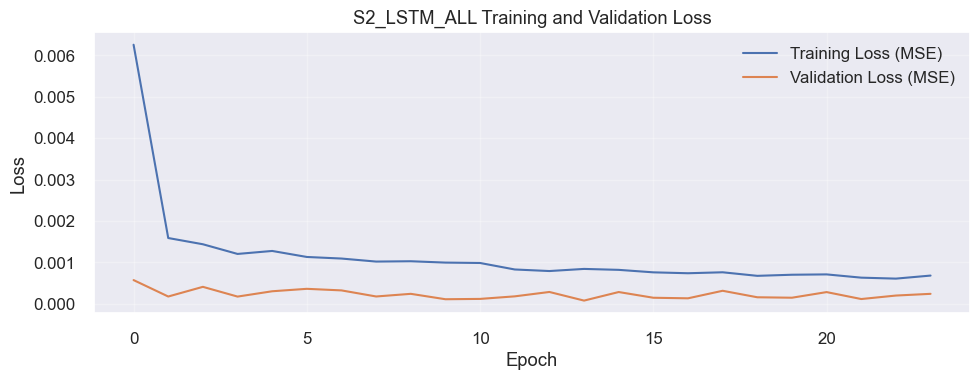

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.plot(
    history.history["loss"],
    label="Training Loss (MSE)"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss (MSE)"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("S2_LSTM_ALL Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Subset1_allfeatures_train_loss

 ### 6. 3.2- Hyperparameter GridSearch

In [ ]:
### COM GRIDSEARCH PARA HIPERPARÂMETROS
def build_lstm(input_shape,
               u1=64, u2=32, u3=16,
               dropout=0.2, lr=1e-3):
    
    model = Sequential([
        LSTM(u1, return_sequences=True, input_shape=input_shape),
        Dropout(dropout),
        LSTM(u2, return_sequences=True),
        Dropout(dropout),
        LSTM(u3, return_sequences=False),
        Dropout(dropout),
        Dense(1)
    ])
    
    model.compile(
        loss="mse",
        optimizer=Adam(lr),
        metrics=["mae"]
    )
    return model

input_shape = (X_train.shape[1], X_train.shape[2])

param_grid = [
    {"u1":64,"u2":32,"u3":16,"drop":0.1,"lr":1e-3,"batch":16,"epochs":50},
    {"u1":128,"u2":64,"u3":32,"drop":0.05,"lr":5e-4,"batch":32,"epochs":50},
    {"u1":256,"u2":128,"u3":64,"drop":0.1,"lr":1e-3,"batch":32,"epochs":50},
]

best_loss = np.inf
best_params = None
best_model = None

for p in param_grid:
    print("\nTesting config:", p)
    
    model = build_lstm(
        input_shape,
        p["u1"], p["u2"], p["u3"],
        p["drop"], p["lr"]
    )
    
    es = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
    
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=p["epochs"],
        batch_size=p["batch"],
        callbacks=[es],
        verbose=1
    )
    
    vloss = min(hist.history["val_loss"])
    print("Val loss:", vloss)
    
    if vloss < best_loss:
        best_loss = vloss
        best_params = p
        best_model = model

print("\nBest config:", best_params)
print("Best val loss:", best_loss)

 ## 7. Retrain Best Model on Train + Val

In [ ]:
# SKIP THIS IF MODEL ALREADY TRAINED WITH BEST PARAMS
X_full = np.concatenate([X_train, X_val])
y_full = np.concatenate([y_train, y_val])

final_model = build_lstm(
    input_shape,
    best_params["u1"],
    best_params["u2"],
    best_params["u3"],
    best_params["drop"],
    best_params["lr"]
)

es = EarlyStopping(
    monitor="loss",
    patience=10,
    restore_best_weights=True
)

final_model.fit(
    X_full, y_full,
    epochs=best_params["epochs"],
    batch_size=best_params["batch"],
    callbacks=[es],
    verbose=1
)

 ## 8. Evaluation on Test Set

49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step
R²  = 0.984872906635507
MAE = 0.05521504337731934
RMSE= 0.07128537101851111
NSE = 0.984872906635507


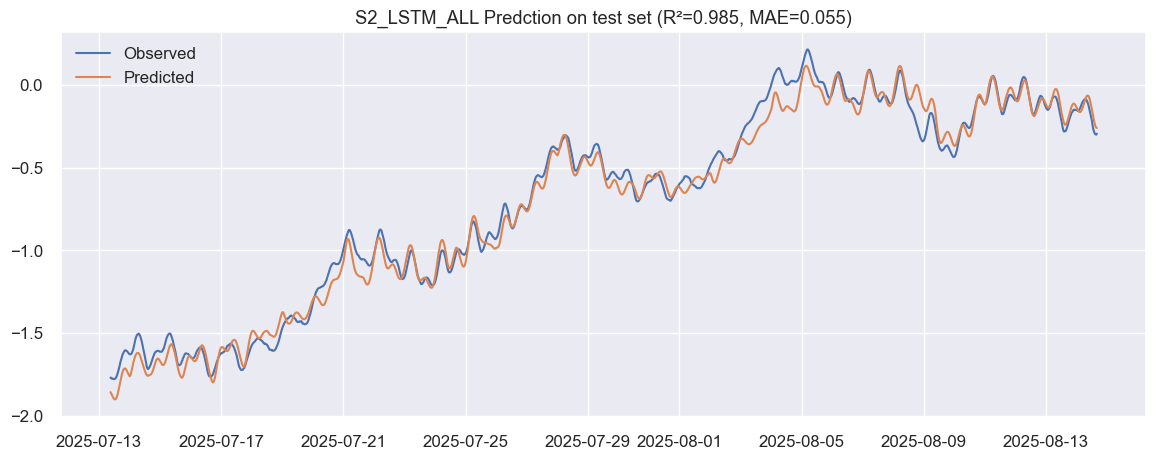

In [10]:
y_pred_scaled = final_model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

r2   = r2_score(y_true, y_pred)
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
nse  = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)

print("R²  =", r2)
print("MAE =", mae)
print("RMSE=", rmse)
print("NSE =", nse)

timestamps = df_model.index[
    window_size + val_end :
    window_size + val_end + len(y_test)
]

plt.figure(figsize=(14,5))
plt.plot(timestamps, y_true, label="Observed")
plt.plot(timestamps, y_pred, label="Predicted")
plt.title(f"S2_LSTM_ALL Predction on test set (R²={r2:.3f}, MAE={mae:.3f})")
plt.legend()
plt.grid(True)
plt.show()

# subset1_lagonly_LSTM_predXreal_graph


### Residual Time Series (Test − Prediction)

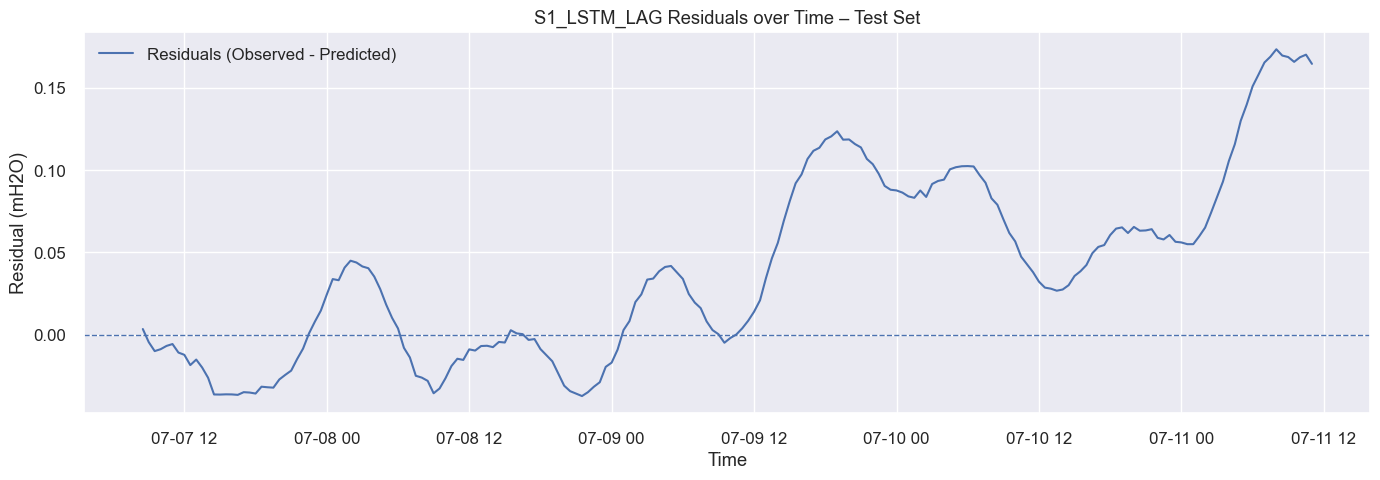

In [14]:
# ==========================================================
# Residual analysis
# ==========================================================

# Compute residuals
residuals = y_true.flatten() - y_pred.flatten()

# ----------------------------------------------------------
# Plot residuals over time
# ----------------------------------------------------------
plt.figure(figsize=(14, 5))

plt.plot(
    timestamps,
    residuals,
    label="Residuals (Observed - Predicted)"
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Time")
plt.ylabel("Residual (mH2O)")
plt.title("S1_LSTM_LAG Residuals over Time – Test Set")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# subset1_allfeatures_LSTM_residuals



### Residual Distribution

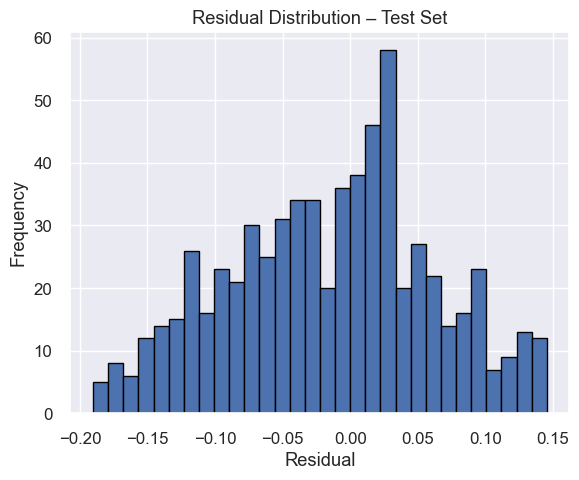

In [18]:
# ----------------------------------------------------------
# Residual distribution
# ----------------------------------------------------------
plt.figure(figsize=(6, 5))

plt.hist(residuals, bins=30, edgecolor="black")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution – Test Set")
plt.grid(True)
plt.tight_layout()
plt.show()

### Residuals vs Physical and Operational Features
 Align residuals with original dataset

In [16]:
# Create DataFrame with residuals indexed by time
df_residuals = pd.DataFrame(
    {
        "residual": residuals.flatten()
    },
    index=timestamps
)

# Select features from original dataset
features_to_analyze = [
    "baro_ig_mH2O",
    "rain_mm_30min",
    "status_IME",
    "status_FEF",
    "status_IBZ",
    "earth_tide_nm/s2"
]

df_features = df.loc[df_residuals.index, features_to_analyze]

# Merge
df_res = pd.concat([df_residuals, df_features], axis=1).dropna()

print("Residual-feature dataset shape:", df_res.shape)
df_res.head()

Residual-feature dataset shape: (198, 7)


,residual,baro_ig_mH2O,rain_mm_30min,status_IME,status_FEF,status_IBZ,earth_tide_nm/s2
date_time,,,,,,,
2022-07-07 08:30:00,0.003443,9.681907,0.0,1.0,1.0,1.0,-577.689
2022-07-07 09:00:00,-0.004528,9.685492,0.0,1.0,1.0,1.0,-587.391
2022-07-07 09:30:00,-0.009966,9.687039,0.0,1.0,1.0,1.0,-569.040
2022-07-07 10:00:00,-0.008808,9.686055,0.0,1.0,1.0,1.0,-522.462
2022-07-07 10:30:00,-0.006811,9.688094,0.0,1.0,1.0,1.0,-449.163


### Residual vs Feature Plots

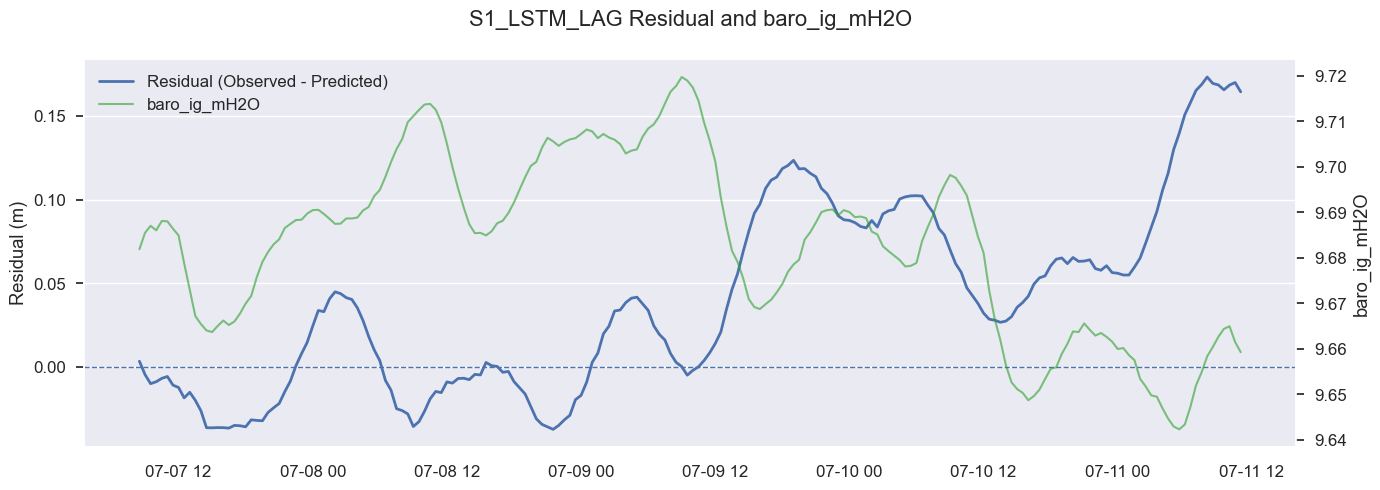

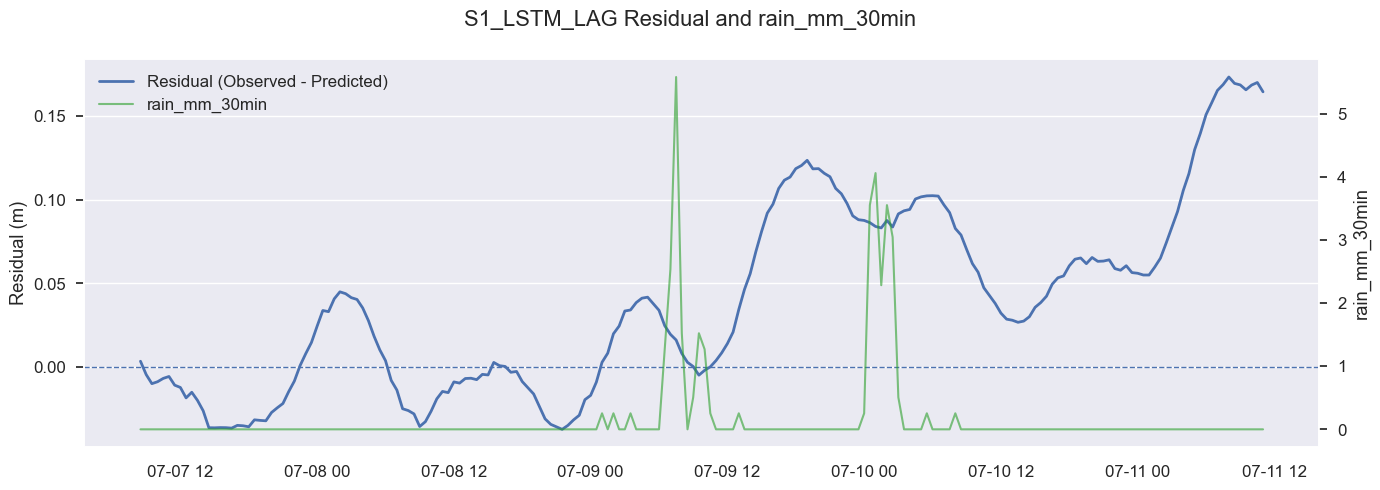

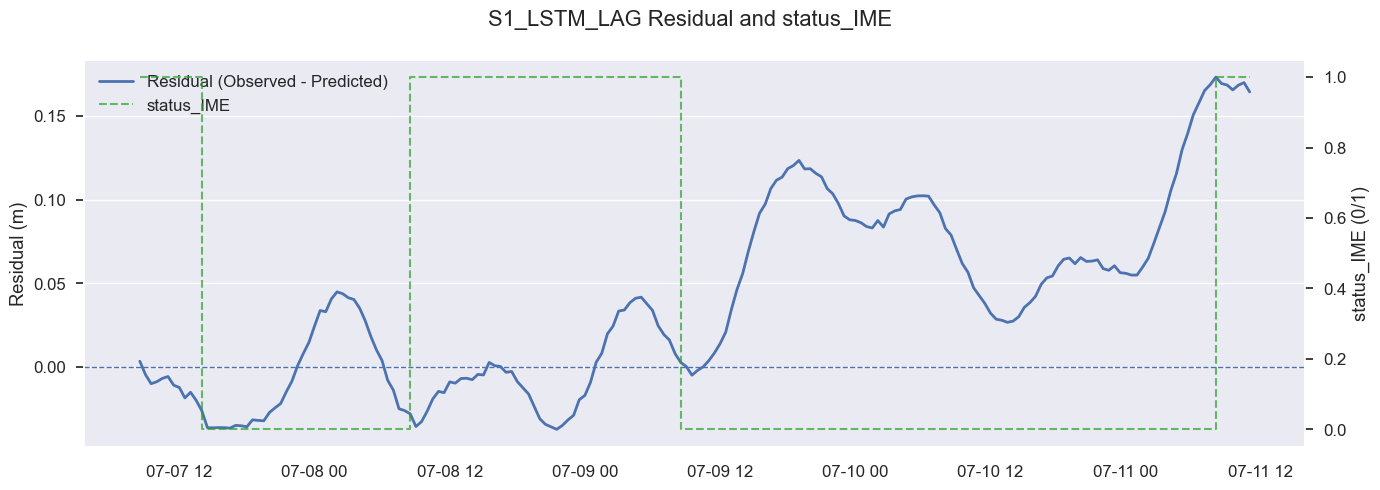

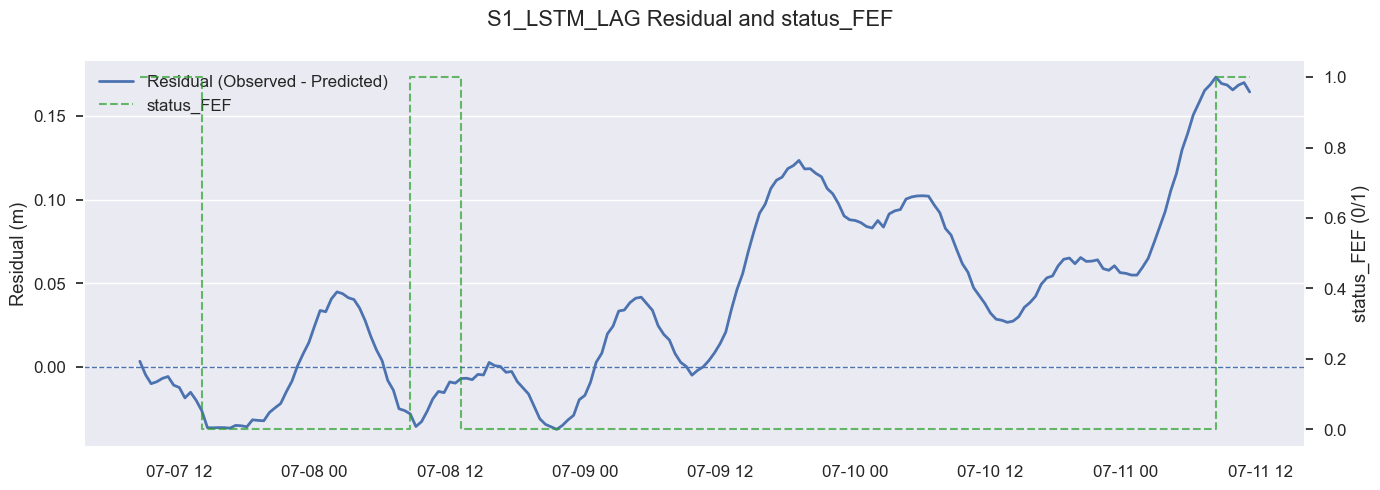

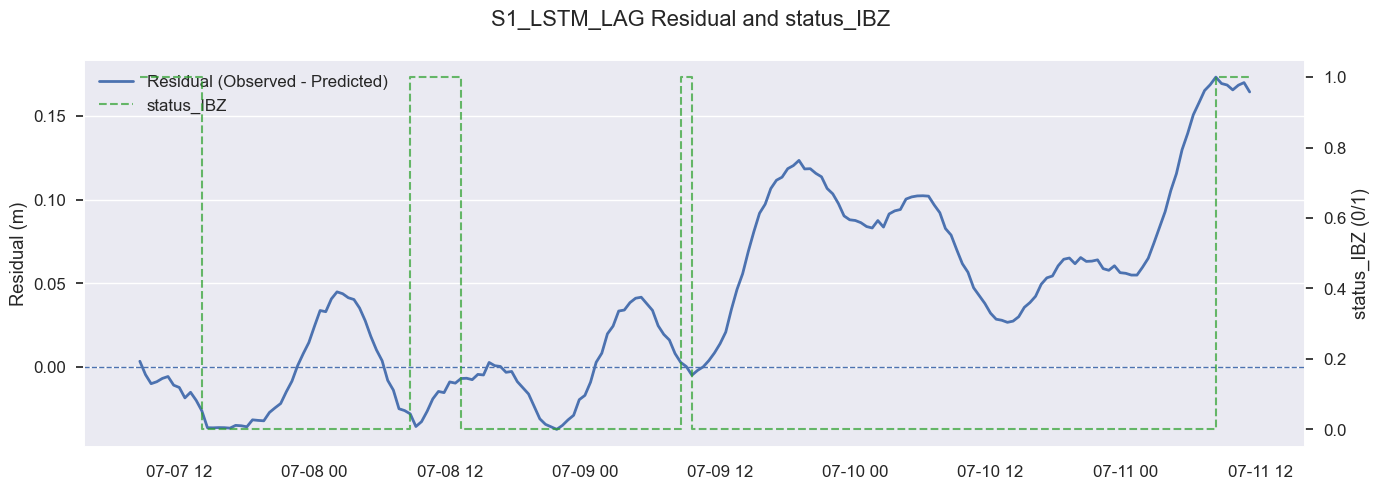

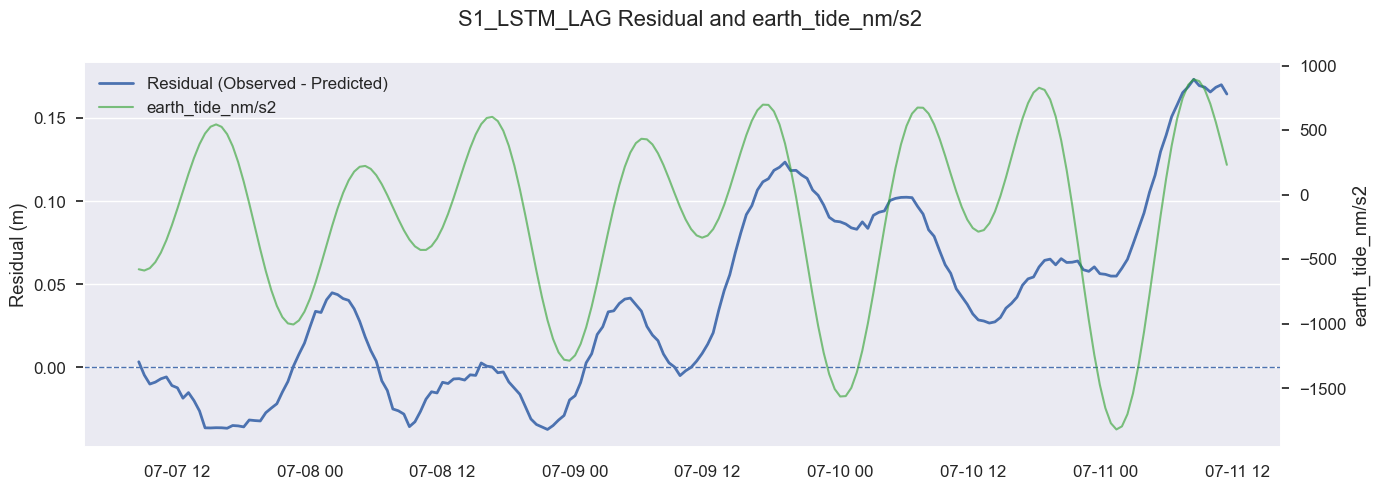

In [ ]:
# ----------------------------------------------------------
# Analysis over the FULL test period
# ----------------------------------------------------------

rename_map = {
    "pressao_mH2O_final": "baro_ig_mH2O",
    "chuva_mm_30min": "rain_mm_30min"
}

FEATURE_COLOR = "tab:green"   # <<< verde claro padrão do matplotlib

for feat in features_to_analyze:
    
    feat_label = rename_map.get(feat, feat)

    fig, ax1 = plt.subplots(figsize=(14, 5))
    
    # Plot residuals
    ax1.plot(
        df_res.index,
        df_res["residual"],
        label="Residual (Observed - Predicted)",
        linewidth=2
    )
    ax1.set_ylabel("Residual (m)")
    ax1.axhline(0, linestyle="--", linewidth=1)
    
    # Second axis for feature
    ax2 = ax1.twinx()
    
    if df_res[feat].nunique() <= 2:
        ax2.step(
            df_res.index,
            df_res[feat],
            where="post",
            linestyle="--",
            alpha=0.7,
            color=FEATURE_COLOR,     # <<< AQUI
            label=feat_label
        )
        ax2.set_ylabel(f"{feat_label} (0/1)")
    else:
        ax2.plot(
            df_res.index,
            df_res[feat],
            alpha=0.6,
            color=FEATURE_COLOR,     # <<< AQUI
            label=feat_label
        )
        ax2.set_ylabel(feat_label)
    
    # Title and legend
    fig.suptitle(f"S1_LSTM_LAG Residual and {feat_label}")
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    
    # Grid configuration
    ax1.grid(axis="x")
    ax2.grid(False)
    
    fig.tight_layout()
    plt.show()


### Pearson Correlation between Residuals and Features

In [24]:
pearson_results = []

for feat in features_to_analyze:
    corr = df_res["residual"].corr(df_res[feat], method="pearson")
    pearson_results.append((feat, corr))

pearson_df = pd.DataFrame(
    pearson_results,
    columns=["Feature", "Pearson_r"]
).sort_values("Pearson_r", key=np.abs, ascending=False)

pearson_df

,Feature,Pearson_r
0,baro_ig_mH2O,-0.497647
2,status_IME,-0.324433
5,earth_tide_nm/s2,0.177418
4,status_IBZ,-0.063810
1,rain_mm_30min,0.054085
3,status_FEF,-0.045892


### Cross-Correlation Analysis (Residual × Feature)

c:\Users\peliz\anaconda3\Lib\site-packages\numpy\lib\function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\peliz\anaconda3\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\peliz\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\peliz\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\peliz\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\Users\peliz\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\peliz\anaconda3\Lib\site-packages\numpy\lib\function_base.py:

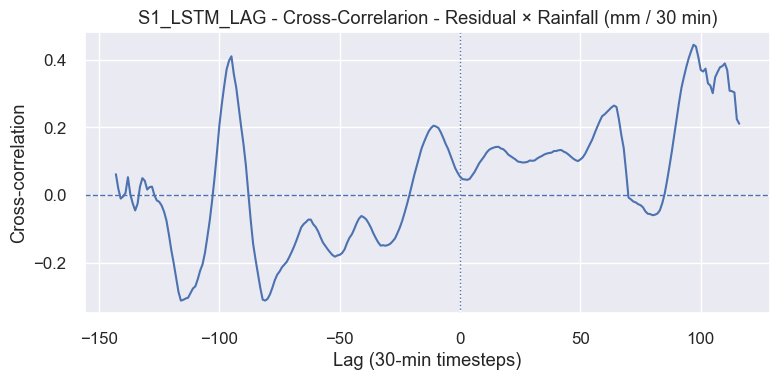

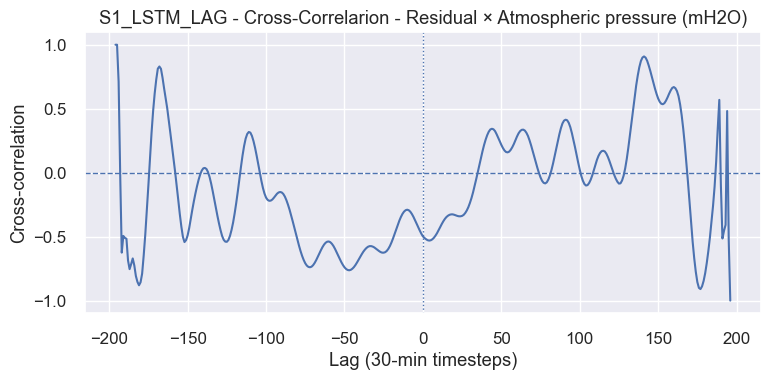

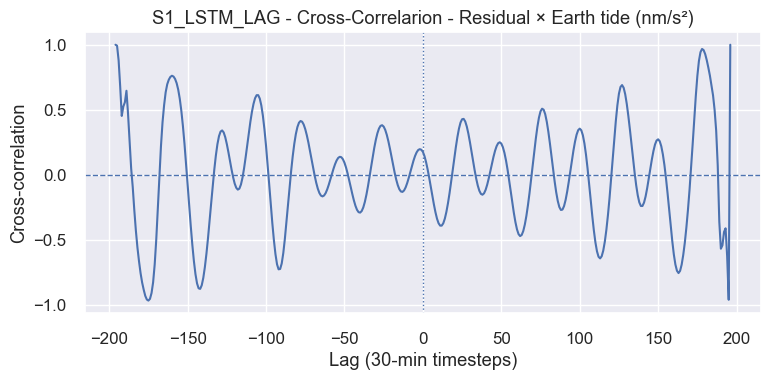

In [ ]:
def cross_correlation(x, y, max_lag):
    lags = np.arange(-max_lag, max_lag + 1)
    ccs = []

    for lag in lags:
        if lag < 0:
            ccs.append(np.corrcoef(x[:lag], y[-lag:])[0, 1])
        elif lag > 0:
            ccs.append(np.corrcoef(x[lag:], y[:-lag])[0, 1])
        else:
            ccs.append(np.corrcoef(x, y)[0, 1])

    return lags, np.array(ccs)

# Only continuous features
continuous_features = {
    "rain_mm_30min": "Rainfall (mm / 30 min)",
    "baro_ig_mH2O": "Atmospheric pressure (mH2O)",
    "earth_tide_nm/s2": "Earth tide (nm/s²)"
}

max_lag = 480  # ±10 days for 30-min data

x = df_res["residual"].values

for feat, label in continuous_features.items():

    y = df_res[feat].values

    mask = ~np.isnan(x) & ~np.isnan(y)
    x_f = x[mask]
    y_f = y[mask]

    lags, ccs = cross_correlation(x_f, y_f, max_lag)

    plt.figure(figsize=(8, 4))
    plt.plot(lags, ccs)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axvline(0, linestyle=":", linewidth=1)
    plt.xlabel("Lag (30-min timesteps)")
    plt.ylabel("Cross-correlation")
    plt.title(f"S1_LSTM_LAG - Cross-Correlarion - Residual × {label}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # S1_LSTM_LAG_CrossCor_residual_

### Before–After Analysis for Binary Operational Variables

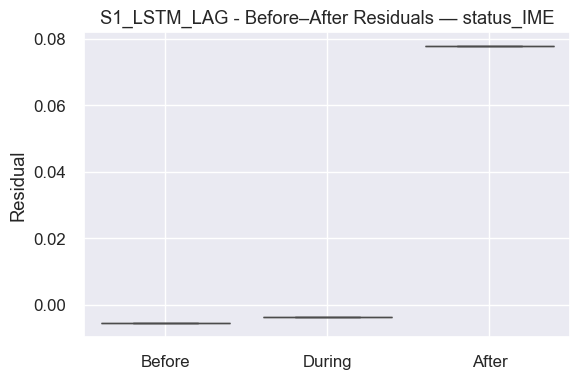


status_IME — Mean residuals:
Before   -0.005551
During   -0.003714
After     0.077938
dtype: float64


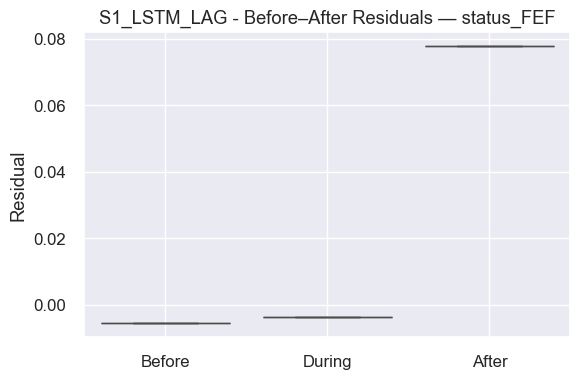


status_FEF — Mean residuals:
Before   -0.005551
During   -0.003714
After     0.077938
dtype: float64


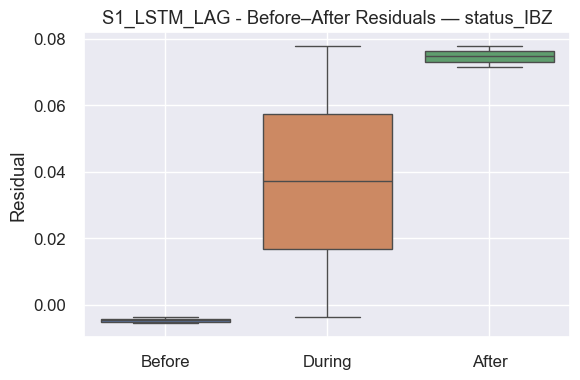


status_IBZ — Mean residuals:
Before   -0.004633
During    0.037112
After     0.074737
dtype: float64


In [ ]:
def before_after_analysis(
    df,
    status_col,
    residual_col="residual",
    pre_steps=48,
    post_steps=48
):
    """
    Computes mean residual before, during, and after operational events.
    """
    
    events = df.index[df[status_col].diff() == 1]  # OFF → ON
    
    records = []

    for t0 in events:
        idx = df.index.get_loc(t0)

        if idx - pre_steps < 0 or idx + post_steps >= len(df):
            continue

        before = df.iloc[idx - pre_steps:idx][residual_col].mean()
        during = df.iloc[idx:idx + pre_steps][residual_col].mean()
        after  = df.iloc[idx + pre_steps:idx + pre_steps + post_steps][residual_col].mean()

        records.append([before, during, after])

    return pd.DataFrame(
        records,
        columns=["Before", "During", "After"]
    )

status_vars = [
    "status_IME",
    "status_FEF",
    "status_IBZ"
]

for status in status_vars:
    
    ba = before_after_analysis(
        df_res,
        status_col=status,
        pre_steps=48,   # 24h
        post_steps=48
    )
    
    if ba.empty:
        print(f"No valid events for {status}")
        continue

    plt.figure(figsize=(6, 4))
    sns.boxplot(data=ba)
    plt.title(f"S1_LSTM_LAG - Before–After Residuals — {status}")
    plt.ylabel("Residual")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"\n{status} — Mean residuals:")
    print(ba.mean())

# S1_LSTM_LAG_BA_residual_


### Superposed Epoch Analysis (SEA)

No valid epochs for status_IME
No valid epochs for status_FEF


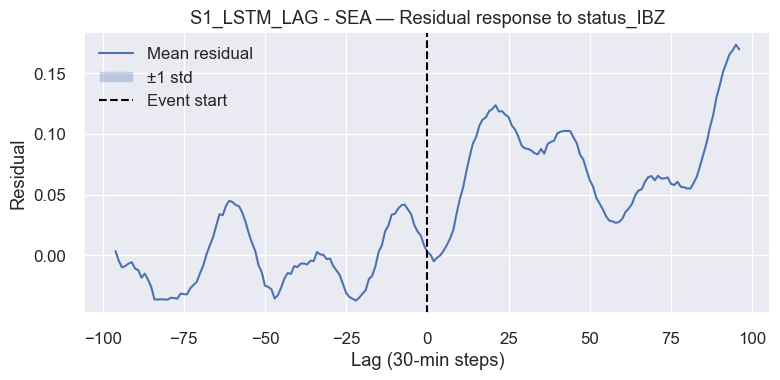

In [ ]:
def superposed_epoch_analysis(
    df,
    status_col,
    residual_col="residual",
    window=96
):
    """
    Computes SEA around ON events.
    """
    
    events = df.index[df[status_col].diff() == 1]
    epochs = []

    for t0 in events:
        idx = df.index.get_loc(t0)

        if idx - window < 0 or idx + window >= len(df):
            continue

        epoch = df.iloc[idx - window:idx + window + 1][residual_col].values
        epochs.append(epoch)

    return np.array(epochs)

for status in status_vars:
    
    epochs = superposed_epoch_analysis(
        df_res,
        status_col=status,
        window=96  # ±48h
    )

    if len(epochs) == 0:
        print(f"No valid epochs for {status}")
        continue

    mean_epoch = np.mean(epochs, axis=0)
    std_epoch  = np.std(epochs, axis=0)

    lags = np.arange(-96, 97)

    plt.figure(figsize=(8, 4))
    plt.plot(lags, mean_epoch, label="Mean residual")
    plt.fill_between(
        lags,
        mean_epoch - std_epoch,
        mean_epoch + std_epoch,
        alpha=0.3,
        label="±1 std"
    )
    plt.axvline(0, linestyle="--", color="black", label="Event start")
    plt.xlabel("Lag (30-min steps)")
    plt.ylabel("Residual")
    plt.title(f"S1_LSTM_LAG - SEA — Residual response to {status}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # S1_LSTM_LAG_SEA_residual_

 ## 9. Permutation Feature Importance

49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step


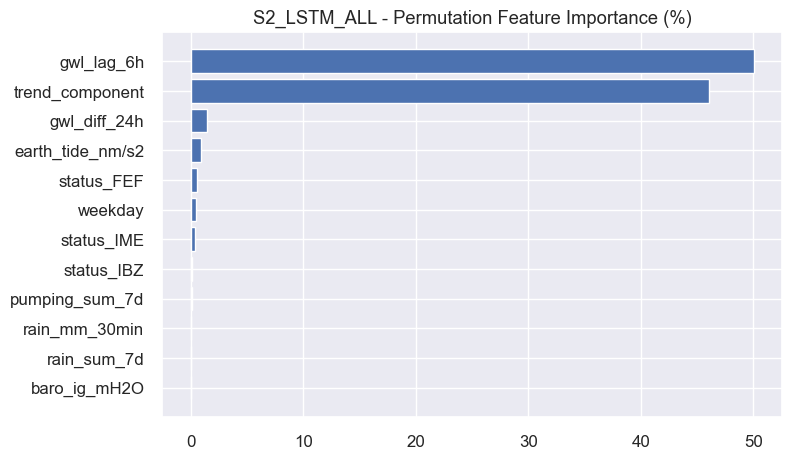

gwl_lag_6h: 50.09%
trend_component: 46.06%
gwl_diff_24h: 1.43%
earth_tide_nm/s2: 0.87%
status_FEF: 0.58%
weekday: 0.46%
status_IME: 0.38%
status_IBZ: 0.09%
pumping_sum_7d: 0.06%
rain_mm_30min: 0.00%
rain_sum_7d: -0.01%
baro_ig_mH2O: -0.02%


In [11]:
base_mse = mean_squared_error(y_test, y_pred_scaled)

feature_names = candidate_features
n_feat = len(feature_names)
importances = []

for j in range(n_feat):
    Xp = X_test.copy()
    perm = np.random.permutation(len(Xp))
    Xp[:, :, j] = Xp[perm, :, j]
    
    y_pp = final_model.predict(Xp)
    mse_p = mean_squared_error(y_test, y_pp)
    
    importances.append(mse_p - base_mse)

importances = np.array(importances)
importances_pct = importances / importances.sum() * 100
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
plt.barh(
    [feature_names[i] for i in sorted_idx][::-1],
    importances_pct[sorted_idx][::-1]
)
plt.title("S2_LSTM_ALL - Permutation Feature Importance (%)")
plt.show()

for i in sorted_idx:
    print(f"{feature_names[i]}: {importances_pct[i]:.2f}%")

 ## 10. SHAP Values (Kernel SHAP for LSTM)

  0%|          | 0/80 [00:00<?, ?it/s]


=== SHAP Global Feature Importance ===
earth_tide_nm/s2: 0.000007
gwl_lag_6h: 0.000006
baro_ig_mH2O: 0.000004
pumping_sum_7d: 0.000004
status_FEF: 0.000004
status_IBZ: 0.000004
gwl_diff_24h: 0.000003
trend_component: 0.000003
status_IME: 0.000002
rain_sum_7d: 0.000002
rain_mm_30min: 0.000002
weekday: 0.000001


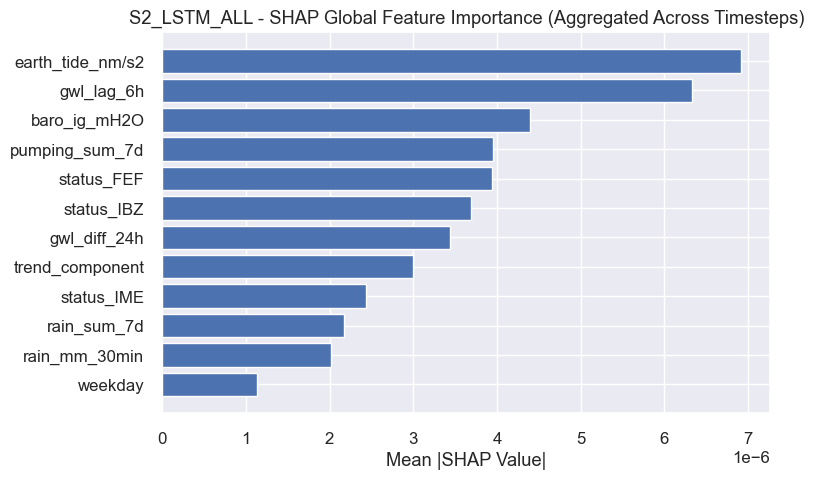

In [12]:
n_samples, time_steps, n_features = X_train.shape

X_train_flat = X_train.reshape((n_samples, time_steps * n_features))
X_background = X_train_flat[:50]

def model_wrapper(x_flat):
    x = x_flat.reshape((x_flat.shape[0], time_steps, n_features))
    return final_model.predict(x, verbose=0)

explainer = shap.KernelExplainer(
    model=model_wrapper,
    data=X_background
)

X_sample = X_train_flat[:80]
shap_values = explainer.shap_values(X_sample, nsamples=200)

shap_values = np.array(shap_values).reshape(
    len(X_sample),
    time_steps,
    n_features
)

mean_abs_shap = np.mean(np.abs(shap_values), axis=(0, 1))
sorted_idx = np.argsort(mean_abs_shap)[::-1]

print("\n=== SHAP Global Feature Importance ===")
for i in sorted_idx:
    print(f"{feature_names[i]}: {mean_abs_shap[i]:.6f}")

plt.figure(figsize=(8,5))
plt.barh(
    [feature_names[i] for i in sorted_idx][::-1],
    mean_abs_shap[sorted_idx][::-1]
)
plt.title("S2_LSTM_ALL - SHAP Global Feature Importance (Aggregated Across Timesteps)")
plt.xlabel("Mean |SHAP Value|")
plt.tight_layout()
plt.show()